In [1]:
import sys
sys.path.append("../../")
from NuChart.src.NuChart import *
import pandas as pd
import numpy as np

# Basic usage of NuChart to produce nuclear chart plots

The NuChart object will create a nuclear chart plot using AME2020 data for stable, observed and extrapolated nuclei. 

Shadow is added automatically but can be turned off with the argument shadow=False. It is done by passing the figure to Pillow and adding a gaussian blur.

The two first argument give the limits in N and Z for the plot.

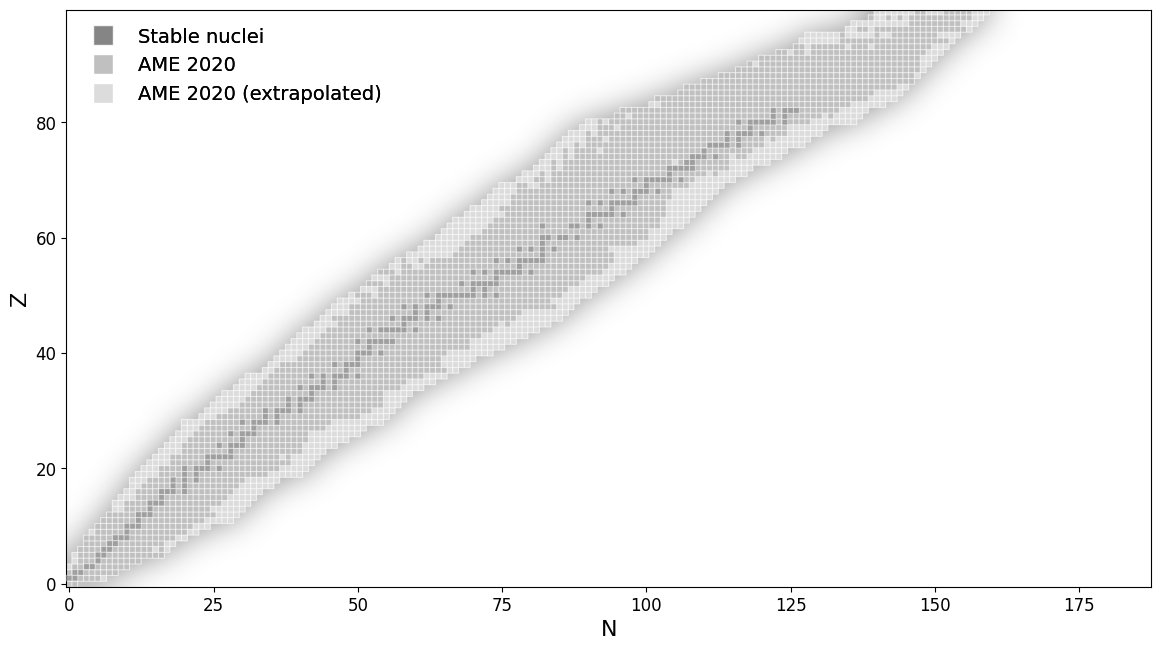

In [2]:
nc = NuChart(xlim=188, ylim=100, figsize=(14,8))

The plot_abinitio() method can be used to show the reach of ab initio methods throught the years. The years included in the plots can be passed as a list through the argument years = []. Colormap can also be changed with the argument cmap.

The method add_magic_numbers() method will add lines at magic numbers for N and Z and will print the numbers on the plots if the spacing permits it.

It is based on the data collected by Heiko Hergert to generate his own version of these plots see e.g. https://doi.org/10.3389/fphy.2020.00379. 

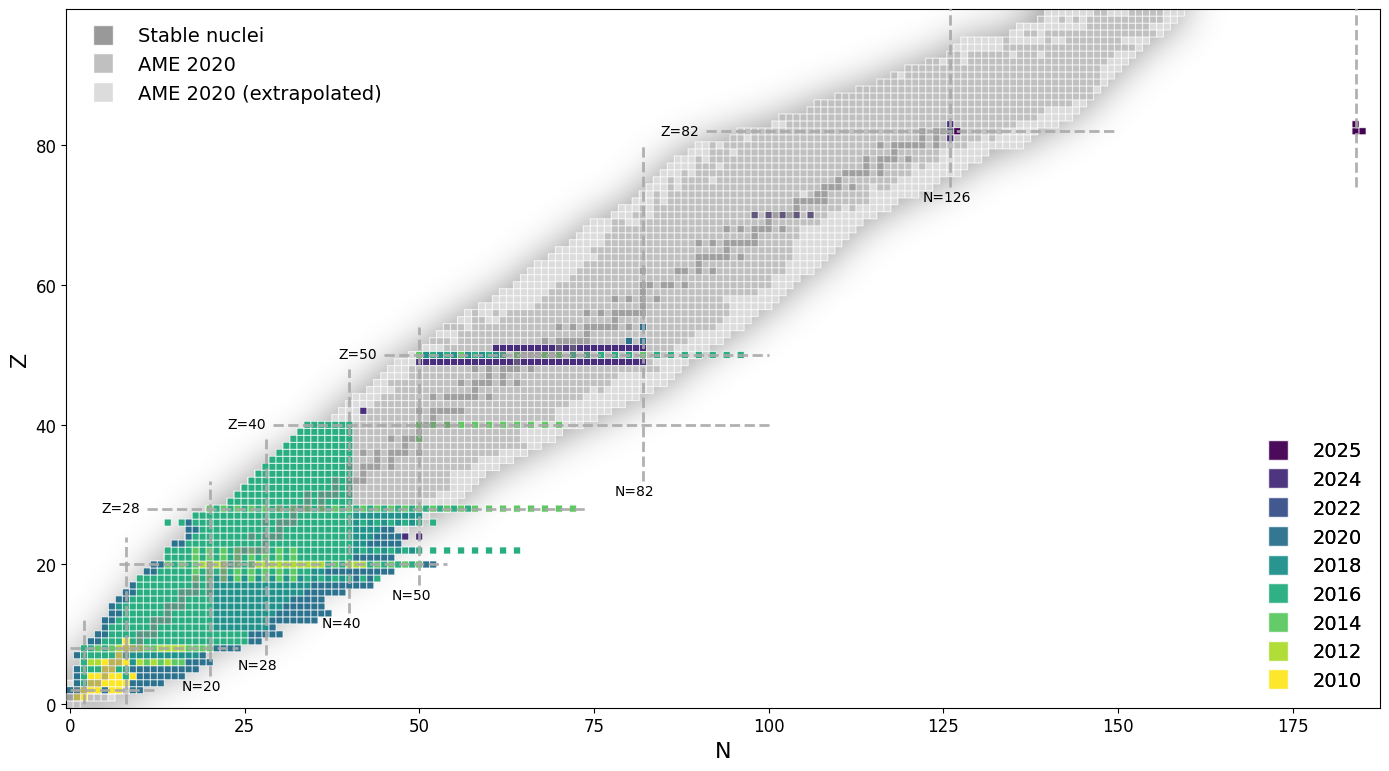

In [3]:
nc = NuChart(188,100, figsize=(14,8))
nc.add_magic_numbers()
nc.plot_abinitio()
nc.savefig("abinitio_evolution.png", dpi=500)

Candidates for specific processes can also be added via the method highlight_candidates().

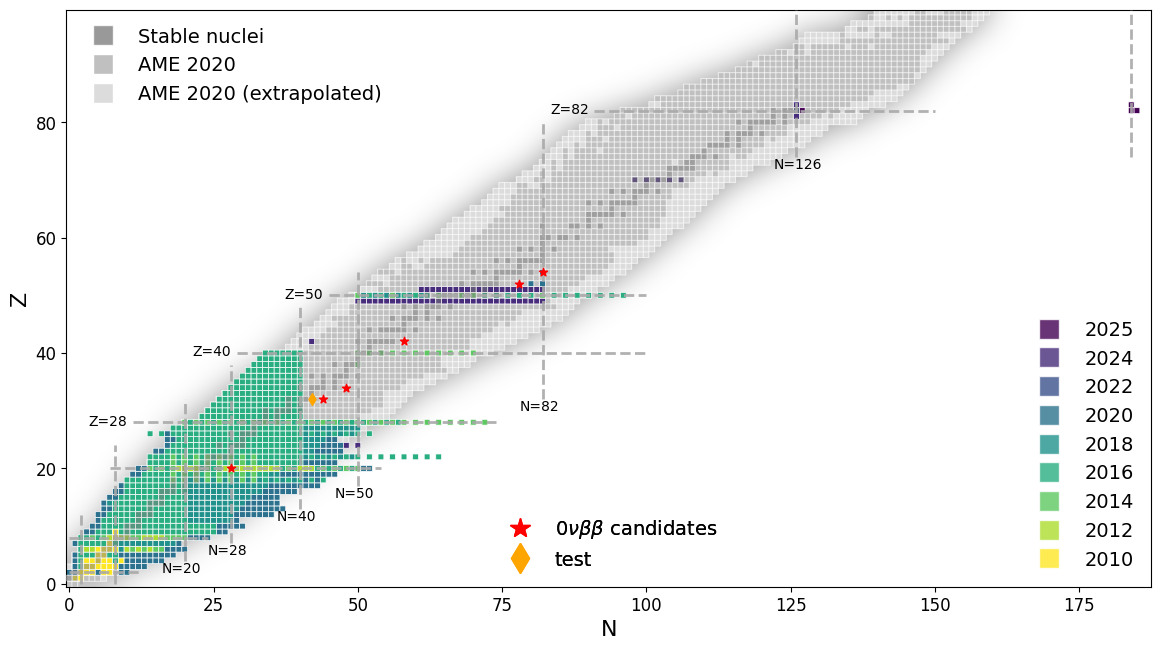

In [9]:
nc = NuChart(188, 100, figsize=(14, 8))
nc.add_magic_numbers()
candidates_0vbb = [(20,48), (32,76), (34,82), (42,100), (52,130), (54,136)]
nc.plot_abinitio()
nc.highlight_candidates(candidates_0vbb, label = r"$0\nu\beta\beta$ candidates",legend=False)
nc.highlight_candidates([(32,74)], marker='d', color='orange', label=r"test")

To plot up to a specific year (to build it year by year in a talk), you can add the argument year_max. This will keep the color scheme consistent.

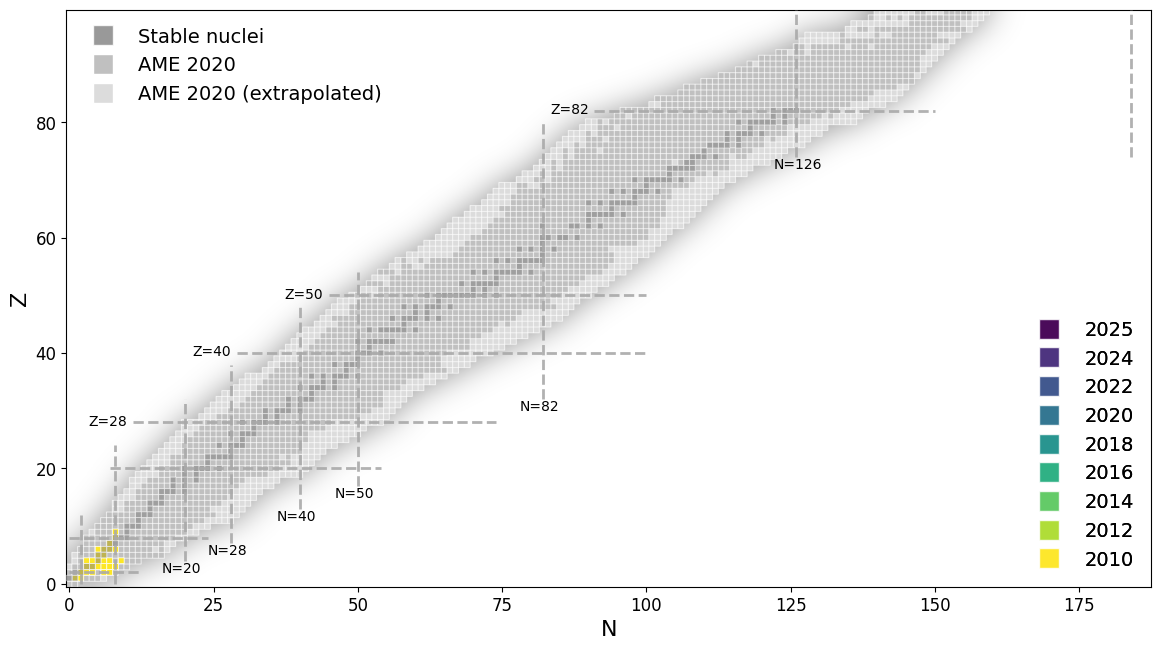

In [5]:
nc = NuChart(188, 100, figsize=(14, 8))
nc.add_magic_numbers()
nc.plot_abinitio(year_max=2010)

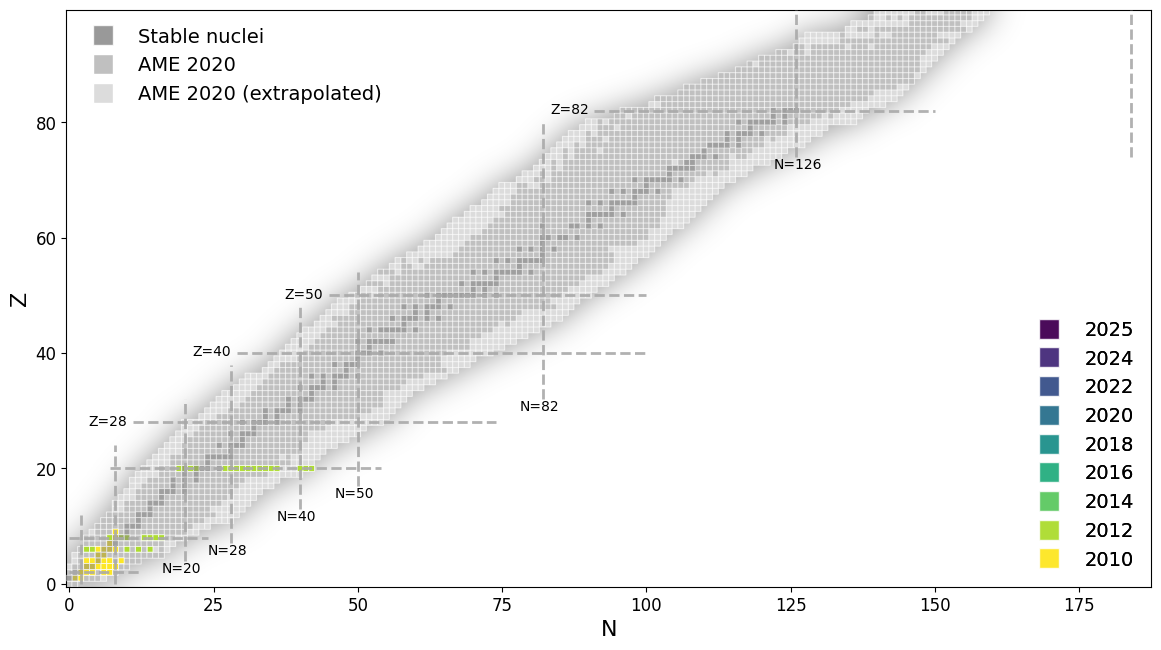

In [6]:
nc = NuChart(188, 100, figsize=(14, 8))
nc.add_magic_numbers()
nc.plot_abinitio(year_max=2012)

The plot_observable() method allows to plot one observable to show the current experimental status of one observable across the nulcear chart. Takes a pandas DataFrame which contains n and z as columns and adds those values of n and z to the plot.

Below is an example for the charge radii based on the IAEA database (https://www-nds.iaea.org/radii/).

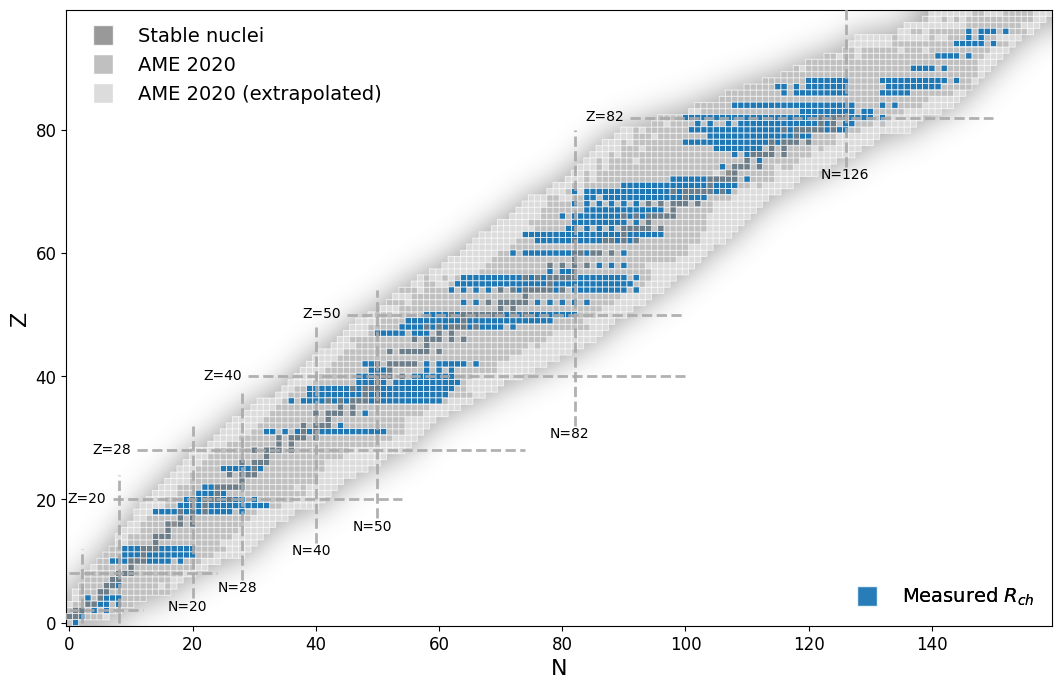

In [7]:
nc = NuChart(160, 100, figsize=(14, 8),alpha_stable=0.8)
nc.add_magic_numbers()
df = pd.read_csv("../Data/nuclear_charge_radii_IAEA.csv")
nc.plot_observable(df, label=r"Measured $R_{ch}$")

More complicated plots can easily be done through some of the higher level functions in the package. For example here is an example to vizualize nuclei for which the electric dipole moment, the electric quadrupole moment or both have been measured.

/var/folders/sm/zf_0m8q16fxf2kp_kqf4dy_40000gn/T/ipykernel_86344/1393733539.py:2: ParserWarning: Skipping line 89: expected 12 fields, saw 17
Skipping line 146: expected 12 fields, saw 17
Skipping line 360: expected 12 fields, saw 17

  df = pd.read_csv('../Data/nuclear_magnetic_dipole_IAEA.csv', on_bad_lines='warn')


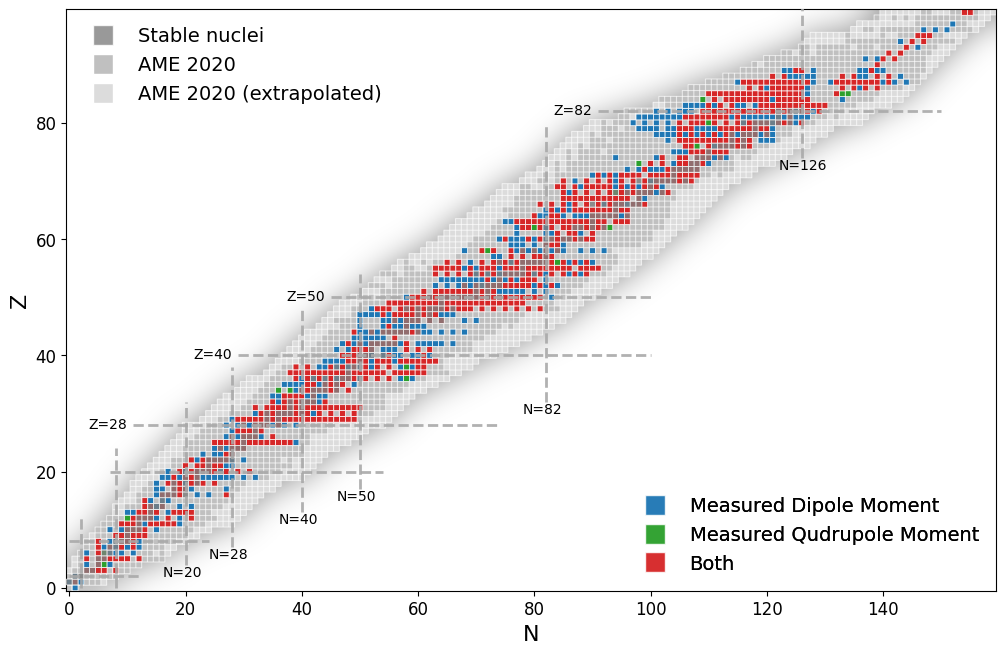

In [8]:
# Create DataFrame from csv for the dipole moment
df = pd.read_csv('../Data/nuclear_magnetic_dipole_IAEA.csv', on_bad_lines='warn')
#Find the values of z and n for which it has been measured from the df
df['n'] = df['n.n+n.z'] - df['z']
coord = df[['z', 'n']].to_numpy()
coord = [tuple(row) for row in coord.tolist()]
#Create X,Y,Z arrays for the pcolormesh plot
Zmax = df['z'].max()+1
Nmax = df['n'].max()+1
X = np.arange(0, Nmax, 1)
Y = np.arange(0, Zmax, 1)
Z = np.full([Zmax, Nmax], np.nan)

#Same for electric quadrupole
df2 = pd.read_csv('../Data/nuclear_electric_quadrupole_IAEA.csv',
                  on_bad_lines='warn')
df2['n'] = df2['n.n+n.z'] - df2['z']
coord2 = df2[['z', 'n']].to_numpy()
coord2 = [tuple(row) for row in coord2.tolist()]

#Assign value to Z array based on if electric dipole, electric quadurpole or both have been measured
for i in coord:
  Z[i[0], i[1]] = 0.5
for i in coord2:
  Z[i[0], i[1]] = 1.5
for i in coord:
  if i in coord2:
    Z[i[0], i[1]] = 2.5

#Create the base figure from AME2020 data
nc = NuChart(figsize=(12, 8), alpha_stable=0.8)

#Plots the value of Z using the three colors given.
nc.plot_Z(X, Y, Z, ['tab:blue', 'tab:green', 'tab:red'], [
       "Measured Dipole Moment", "Measured Qudrupole Moment", "Both"])
nc.add_magic_numbers()

As a final remark, the axis and figure objects of the plot can be obtained via the get_axis() and get_figure() methods if more customization is required.